Published on June 29, 2024. By Marília Prata, MPwolke.

In [17]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objs as go

import plotly
plotly.offline.init_notebook_mode(connected=True)

from pathlib import Path

#Ignore warnings

import warnings
warnings.filterwarnings('ignore')

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/decagon-polypharmacy-csv-gz/ChChSe-Decagon_polypharmacy.csv


#Dedicated to my Mother (age 94) that passed away on June 28, 2024. 

Fortunately, she didn't take many medicine (a.k.a drugs). RIP dear Mum. See you someday.

#Data-Driven Prediction of Drug Effects

Data-Driven Prediction of Drug Effects and Interactions
Authors: NICHOLAS P. TATONETTI, PATRICK P. YE, ROXANA DANESHJOU, AND RUSS B. ALTMAN 

SCIENCE TRANSLATIONAL MEDICINE - 14 Mar 2012 - Vol 4, Issue 125 - p. 125ra31
DOI: 10.1126/scitranslmed.3003377


"When several drugs collide in an individual, the troubling effects can multiply. One goal of the developing field of pharmacogenomics is to make use of clinical data to predict adverse drug events so that future patients can be protected from the sometimes serious consequences. Two new databases, one of drug effects and a second of drug-drug interaction side effects that permit the identification of drug targets, were described to prediction of drug indications, and discovery of drug-class interactions."

"Adverse drug events aren’t merely a nuisance; these toxic interactions can cause debilitating illness and death. The nature of clinical trials doesn’t allow the detection of all serious side effects and drug interactions before approval of the therapy, by regulatory agencies, for use in patients. But these agencies along with pharmaceutical companies, hospitals, and other institutions collect adverse event reports after the drugs are in use in the clinic."

"When delineated in databases and coupled with the impressive computing power now available, these reports have the potential to permit characterization of drug effects at the population level. However, even with the recent move toward electronic health records, adverse event data often lack crucial information about co-prescribed medications, patient demographics and medical histories, and the reasons that a given drug was prescribed in the first place. One can easily see how that lack of such information thwarts the ability to obtain meaningful analyses of drug side effects and interactions."

"The author used an adaptive data-driven approach to correct for the lack of such information—the so-called unknown “covariates.” Using this information, it was developed two comprehensive databases—one of drug effects (Offsides) and another of drug-drug interaction side effects (Twosides)—and then used their new databases to pinpoint drug targets and discover drug-class interactions."

"Finally, the authors validated 47 of the drug-class interactions in an independent analysis of patient electronic health records. When prescribed together, widely used antidepressant drugs (selective serotonin reuptake inhibitors) and thiazide diuretics were associated with an increase in the incidence of prolonged QT, which indicates a delayed repolarization of the heart after a heartbeat. Prolonged QT can increase a patient’s risk of palpitations, fainting, and even sudden death resulting from ventricular fibrillation. Better than tarot cards or crystal balls, the authors show that intricate analyses of observational clinical data can improve physicians’ ability to predict the future—at least with respect to as yet uncharacterized adverse drug effects and interactions."

https://www.science.org/doi/abs/10.1126/scitranslmed.3003377

![](https://www.researchgate.net/publication/329590648/figure/fig2/AS:703072401625091@1544636931678/Framework-for-polypharmacy-and-conceptual-classification-of-outcomes.png)https://www.researchgate.net/figure/Framework-for-polypharmacy-and-conceptual-classification-of-outcomes_fig2_329590648

#Polypharmacy and its Side Effects

Encore trop de prescriptions et de médicaments inappropriés chez les sujets âgés

Still Too Many Inappropriate Prescriptions Among the Elderly 
By Caroline Guignot - June 25, 2024


"In elderly patients, who often have multiple conditions, polypharmacy is often appropriate but entails a risk for adverse events and, sometimes, an increased risk for morbidity and mortality. This risk is particularly apparent when polypharmacy includes potentially inappropriate medications: Those for which the benefit/risk ratio is unfavorable for older adults."

"The definition of polypharmacy remains variable by country, and studies aiming to assess its frequency in different countries are difficult to compare because of the heterogeneity of methodologies implemented (relating to, eg, data sources, patient profiles, and study duration). Researchers conducted a study on the subject across six European countries, and this transnational comparison could help identify principles to apply from one country to another."

"The prevalence of polypharmacy was determined by the prescription of at least five medications over a period of 6 months, excluding treatments for acute conditions, topical treatments, medical devices, and specialist prescriptions. An analysis was conducted to assess the weight of potentially inappropriate medications among prescriptions for opioids, antipsychotics, benzodiazepines, and proton pump inhibitors (PPIs)."

"The study populations generally were comparable between countries (average age, 75-76 years; 54%-56% women). The prevalence of polypharmacy varied from 22.8% in the United Kingdom to 58.3% in Germany and that of the prescription of ≥ 10 medications ranged from 11.3% in the United Kingdom to 28.5% in Germany. In France, the prevalence of these two levels of polypharmacy was 58.0% and 22.9%, respectively. The Charlson Comorbidity Index was zero for 33.7% (Germany) to 68.7% (United Kingdom) of included patients (58.8% in France)."

"The percentage of potentially inappropriate medication prescriptions was highest for PPIs, ranging from 42.3% to 65.5% (48.4% in France). The inappropriate use of benzodiazepines affected between 2.7% and 34.9% of patients (20.7% in France). The inappropriate prescription of opioids ranged from 11.1% (in France) to 27.5% and that of antipsychotics ranged from 2.1% (in France) to 10.8%."

"Diabetes and chronic respiratory diseases were the most frequently represented comorbidities in patients with polypharmacy. The most commonly prescribed treatment groups were gastrointestinal and cardiovascular medications (eg, antiulcer, antithrombotic, beta blocking, and lipid-lowering agents)."

https://snap.stanford.edu/biodata/datasets/10017/10017-ChChSe-Decagon.html


In [18]:
df = pd.read_csv('/kaggle/input/decagon-polypharmacy-csv-gz/ChChSe-Decagon_polypharmacy.csv', delimiter=',', encoding='utf-8', nrows=1000)

df.tail()

,# STITCH 1,STITCH 2,Polypharmacy Side Effect,Side Effect Name
995,CID000004107,CID000004917,C0027947,Neutropenia
996,CID000004107,CID000004917,C0042024,Incontinence
997,CID000004107,CID000004917,C0020538,High blood pressure
998,CID000004107,CID000004917,C0035317,retinal bleeding
999,CID000004107,CID000004917,C0011175,dehydration


#No Missing Values

In [3]:
df.isnull().sum()

# STITCH 1                  0
STITCH 2                    0
Polypharmacy Side Effect    0
Side Effect Name            0
dtype: int64

In [4]:
df['Side Effect Name'].value_counts()

Side Effect Name
arterial pressure NOS decreased    28568
anaemia                            27006
Difficulty breathing               26037
nausea                             25190
neumonia                           24430
                                   ...  
estrogen replacement                   2
skin abrasion                          2
neurofibromatosis                      2
dwarfism                               2
rabies                                 1
Name: count, Length: 1317, dtype: int64

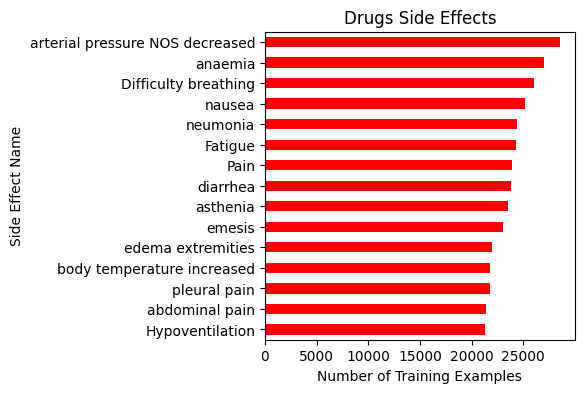

In [5]:
#By Rob Mulla https://www.kaggle.com/code/robikscube/sign-language-recognition-eda-twitch-stream

fig, ax = plt.subplots(figsize=(4, 4))
df["Side Effect Name"].value_counts().head(15).sort_values(ascending=True).plot(
    kind="barh", color='r', ax=ax, title="Drugs Side Effects"
)
ax.set_xlabel("Number of Training Examples")
plt.show()

#Rename columns

In [19]:
df = df.rename(columns={'Polypharmacy Side Effect':'polypharmacy', 'Side Effect Name': 'side_effect'})

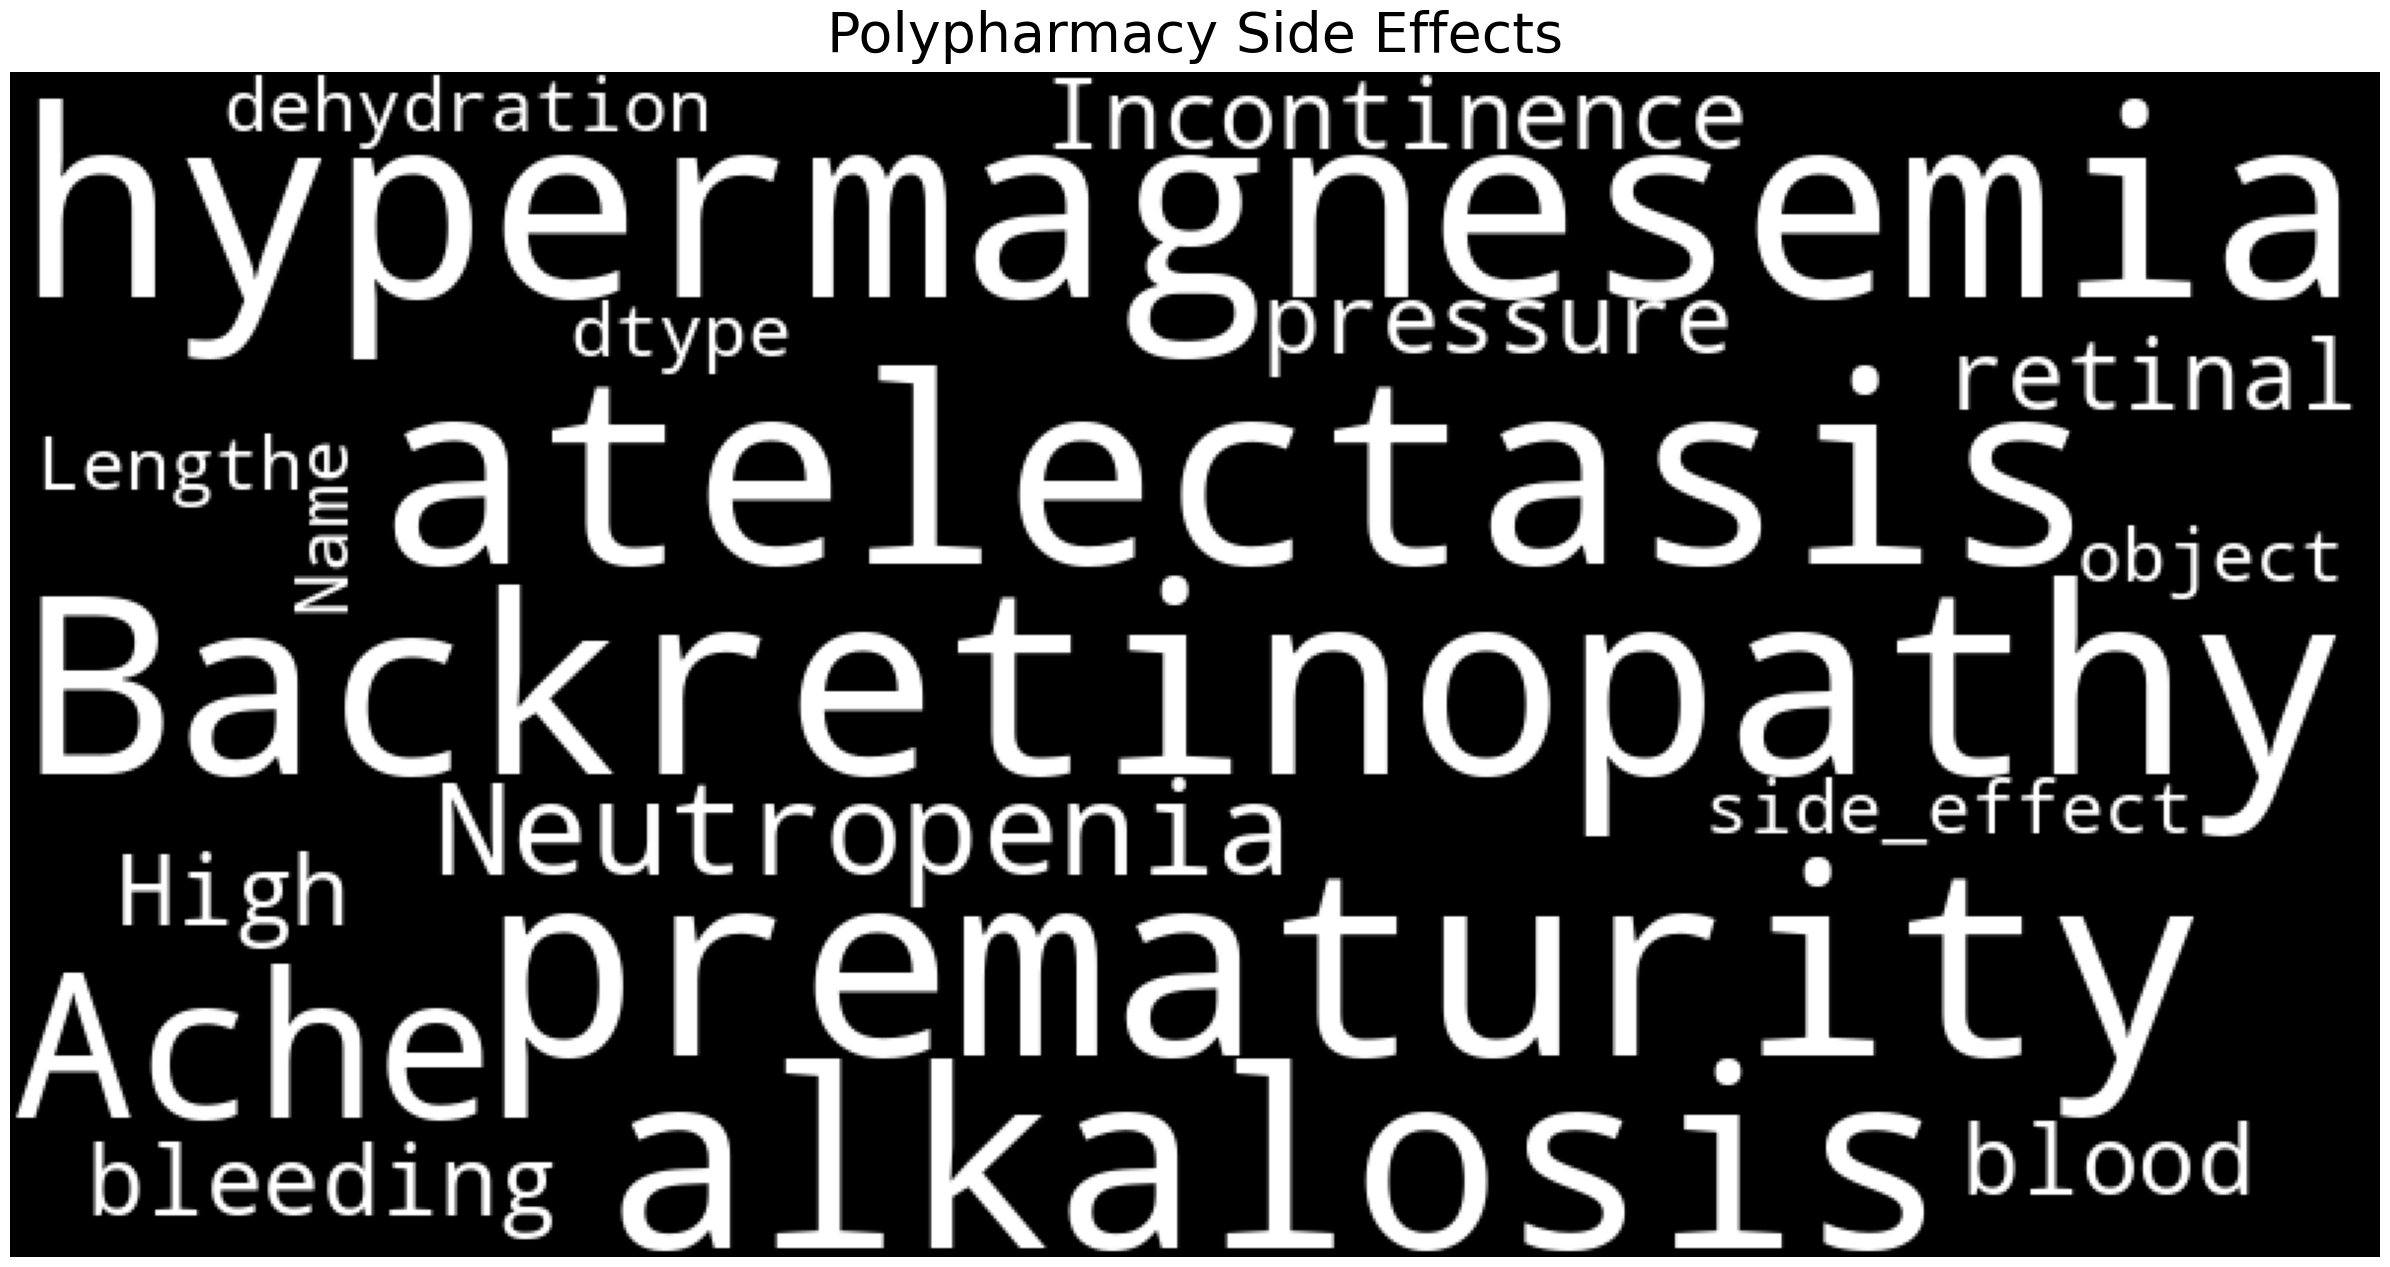

In [20]:
#By SRK https://www.kaggle.com/code/sudalairajkumar/simple-exploration-notebook-qiqc

from wordcloud import WordCloud, STOPWORDS

# Thanks : https://www.kaggle.com/aashita/word-clouds-of-various-shapes ##
def plot_wordcloud(text, mask=None, max_words=200, max_font_size=100, figure_size=(24.0,16.0), 
                   title = None, title_size=40, image_color=False):
    stopwords = set(STOPWORDS)
    more_stopwords = {'one', 'br', 'Po', 'th', 'sayi', 'fo', 'Unknown'}
    stopwords = stopwords.union(more_stopwords)

    wordcloud = WordCloud(background_color='black',
                    color_func=lambda *args, **kwargs: "white",      
                    stopwords = stopwords,
                    max_words = max_words,
                    max_font_size = max_font_size, 
                    random_state = 42,
                    width=800, 
                    height=400,
                    mask = mask)
    wordcloud.generate(str(text))
    
    plt.figure(figsize=figure_size)
    if image_color:
        image_colors = ImageColorGenerator(mask);
        plt.imshow(wordcloud.recolor(color_func=image_colors), interpolation="bilinear");
        plt.title(title, fontdict={'size': title_size,  
                                  'verticalalignment': 'bottom'})
    else:
        plt.imshow(wordcloud);
        plt.title(title, fontdict={'size': title_size, 'color': 'black', 
                                  'verticalalignment': 'bottom'})
    plt.axis('off');
    plt.tight_layout()  
    
plot_wordcloud(df["side_effect"], title="Polypharmacy Side Effects")

In [29]:
%env TOKENIZERS_PARALLELISM=false
!pip install --quiet keybert
print('pip install keybert complete')

env: TOKENIZERS_PARALLELISM=false
pip install keybert complete


In [30]:
top_df = df[df['side_effect'].isin(df['side_effect'].value_counts().head(n=5).index.tolist())].copy()
top_df['side_effect'].value_counts()

side_effect
Difficulty breathing    8
Hypoventilation         8
confusion               7
anaemia                 7
Pain                    7
Name: count, dtype: int64

In [31]:
from arrow import now
from keybert import KeyBERT
from sklearn.feature_extraction.text import CountVectorizer

MAX_DF = 1.0
MIN_DF = 4
MODEL = 'all-MiniLM-L12-v2'
STOP_WORDS = 'english'

model_start = now()
model = KeyBERT(model=MODEL,)
model.max_seq_length = 4 * 1024
vectorizer = CountVectorizer(ngram_range=(1, 1), stop_words=STOP_WORDS, min_df=MIN_DF, max_df=MAX_DF, )
document_embeddings, word_embeddings = model.extract_embeddings(docs=top_df['side_effect'].values.tolist(), vectorizer=vectorizer, )
print('embedding time: {}'.format(now() - model_start))
print('we have {} documents and {} words.'.format(len(document_embeddings), len(word_embeddings)))
keywords = model.extract_keywords(docs=top_df['side_effect'].values.tolist(), top_n=1, stop_words=STOP_WORDS, vectorizer=vectorizer,
                                  doc_embeddings=document_embeddings, word_embeddings=word_embeddings, min_df=MIN_DF, )
print('model time: {}'.format(now() - model_start))
top_df['keyword'] = [keyword[0][0] if len(keyword) else '-none-' for keyword in keywords]

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.7k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

1_Pooling/config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

embedding time: 0:00:03.942327
we have 37 documents and 6 words.
model time: 0:00:03.972621


In [32]:
top_df['keyword'].value_counts().head(n=5)

keyword
breathing          8
hypoventilation    8
confusion          7
anaemia            7
pain               7
Name: count, dtype: int64

#UMAP

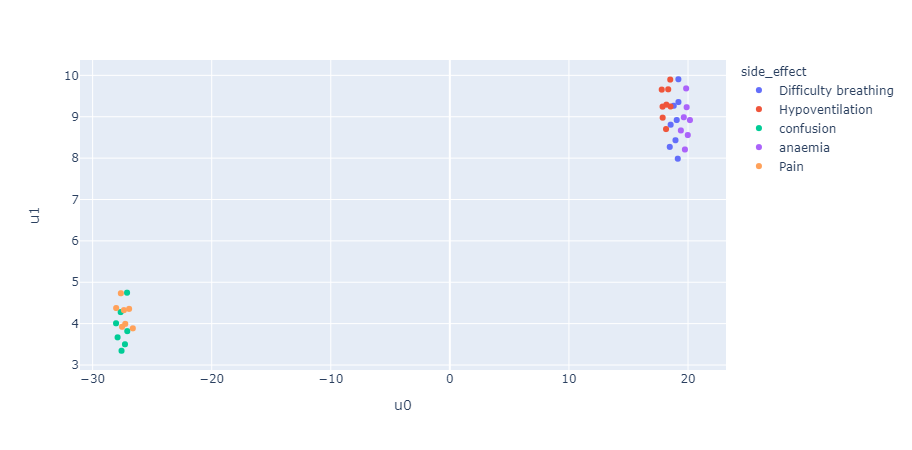

UMAP time: 0:00:09.837587


In [33]:
import pandas as pd
from plotly.express import scatter
from umap import UMAP

umap_start = now()
umap_model = UMAP(n_components=2, random_state=2024, verbose=False, n_jobs=1)
top_df[['u0', 'u1']] = umap_model.fit_transform(X=document_embeddings)
top_df['short text'] = top_df['side_effect'].apply(func=lambda x: ' '.join(x.split()[:20]) + '...')
IGNORE = {'-none-', }
scatter(data_frame=top_df[~top_df['keyword'].isin(IGNORE)], x='u0', y='u1', hover_name='short text',
        hover_data=['keyword', 'polypharmacy', 'side_effect'],
        color = 'side_effect',
       ).show()
print('UMAP time: {}'.format(now() - umap_start))

#Acknowledgements:

Mike Delong https://www.kaggle.com/code/mikedelong/visualize-a-subset-with-umap-embeddings

Rob Mulla https://www.kaggle.com/code/robikscube/sign-language-recognition-eda-twitch-stream

mpwolke https://www.kaggle.com/code/mpwolke/split-video-games-13cols-3-utterances